# Q2 Pairs Trading Framework
###   *by Dr. W. Vera-Tudela*

## 1. Introduction & Objective

This is a custom pairs trading framework built from scratch in Jupyter Notebook with supporting functions in a separate Python file. The framework allows you to test a pair of stocks together and compare them against historical market data to evaluate their performance before risking real capital.

Objectives:
- Provide an evidence-based decision-making tool: Test your trading hypotheses with historical data.
- Allow strategy refinement: Identify strengths and weaknesses in your approach.
- Risk management: Understand potential drawdowns and volatility
- Performance comparison: Benchmark the pair against each stock independently and market indices
- Flexibility: Custom-built framework allows for complete control over testing parameters

This framework provides a solid foundation for quantitative trading strategy development and evaluation.

## 2. Data Pipeline

The structure of the data flow is as follows:

1. Data Management
    - Fetches and cleans real market data from Yahoo Finance
    - Handles historical price data for assets like AAPL and SPY
    - Stores processed data for efficient reuse  

2. Pair Checking and Signal Generation - stationary spread between two assets
    - Checks p-values for each asset and for both as a pair
    - Calculates the spread and z-value
    - Generates a signal to short/long each of the assets 

3. Pairs trading
    - Simulates portfolio evolution with precise cash and position tracking
    - Handles trade execution based on generated signals
    - Manages multiple positions and cash balance throughout the simulation  

4. Performance Analysis
    - Measures performance using multiple meaningful metrics:
        - Returns (absolute and relative)
        - Risk-adjusted metrics (Sharpe ratio)
        - Drawdown analysis (maximum drawdown)
    - Compares strategy performance against independent assets and benchmark indices  

5. Visualisation
    - Displays equity curves to track portfolio growth
    - Shows drawdown charts to visualise risk periods
    - Provides comparative performance visualisations against benchmarks  

This consolidated framework provides a complete pipeline from data acquisition through strategy testing to performance evaluation and visualisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

import sys
sys.path.append('../utils')   # path relative to the notebook
from Q2_functions import check_data, check_signals, run_pairs_trading, compute_metrics, plot_performance
from common import fetch_data

## 3. Signal Generation

The first thing to do is to download the historical data for a given time period, then clean it to remove incomplete values and keep only the relevant columns.  
This is done by the function `fetch_data()`.

In [2]:
# Load data
starting_capital = 10_000
period = 10
end = pd.Timestamp.today(tz="UTC").normalize()
start = end - pd.DateOffset(years=period)

dataV = fetch_data('V', start, end)
dataM = fetch_data('MA', start, end)
dataS = fetch_data('SPY', start, end)

Subsequently, the p-values of each asset are calculated, and the cointegration is also checked. The hedge ratio (β) is calculated, as well as the spread between the two assets over time.  
This is done by the function `check_data()`.

Then, the z-score is obtained and checked for oscillation and outliers. Afterward, the trading signal is generated to short/long each asset depending on the trends.  
This is done by the function `check_signals()`.

V ADF: -0.9191, p-value: 0.7816
MA ADF: -0.9463, p-value: 0.7723
Cointegration p-value: 0.0005
Critical values: [-3.90080167 -3.33856151 -3.04613746]
Hedge ratio β: 0.5540
R²: 0.9919
Spread mean: 24.2123
Spread std: 7.0438


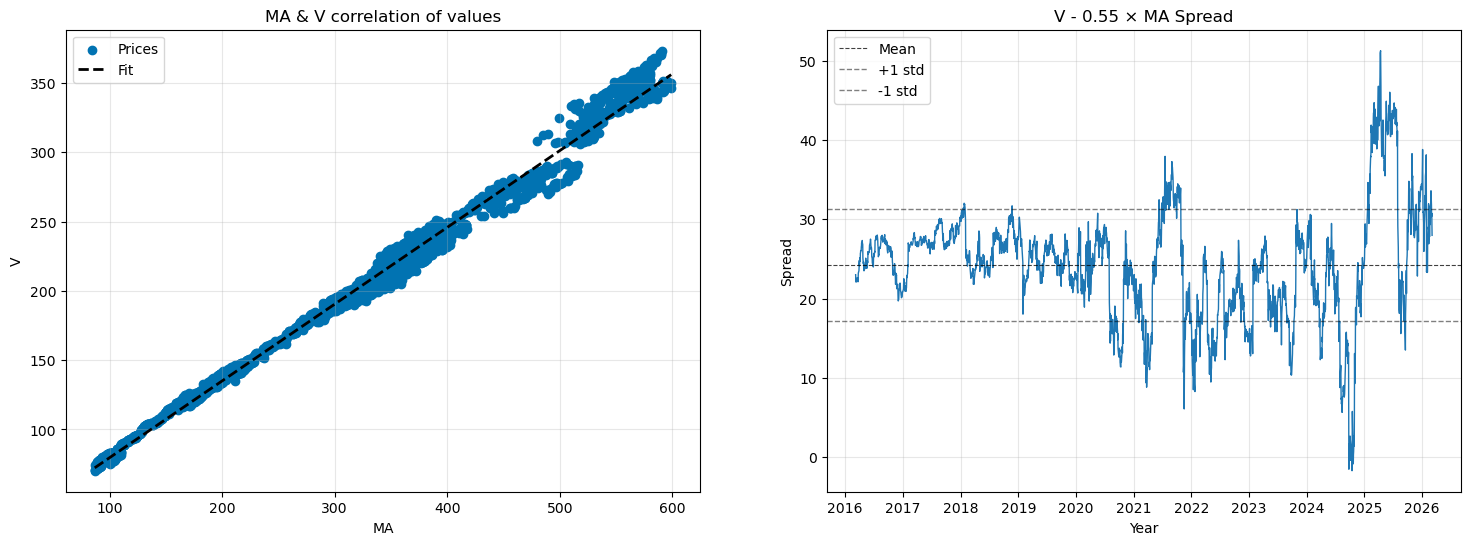

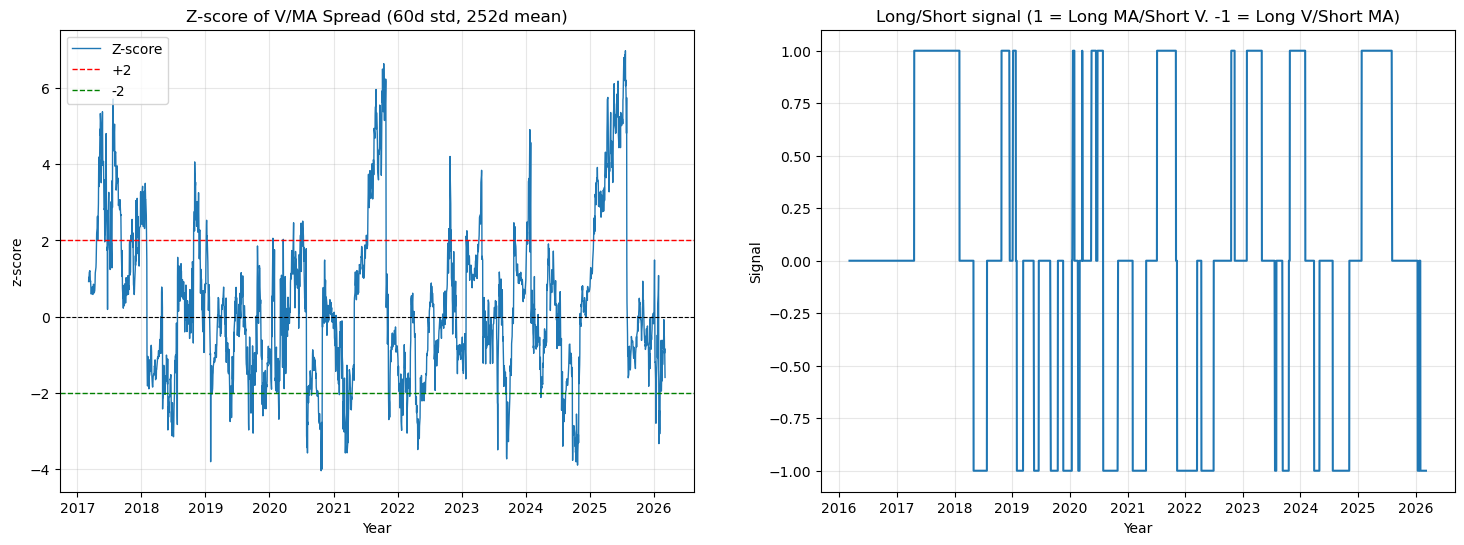

In [3]:
check_data(dataV, dataM)

signal = check_signals(dataV, dataM)

## 4. Pairs Trading Engine
Once the data and signals have been prepared, we move on to the pairs trading engine, the core of this notebook.  
Here, we implement a dual strategy:
1. Long a stock that should go up by buying as many shares as possible, and short a stock that should go down by borrowing an equivalent amount.
2. The previously generated signal tells us when to buy and when to sell. Also, depending on the signal sign (pos/neg) it tells us which stock to short and which to long.  

This is done by the function `run_pairs_trading()`.

In [4]:
dataP = run_pairs_trading(dataV, dataM, signal, starting_capital)

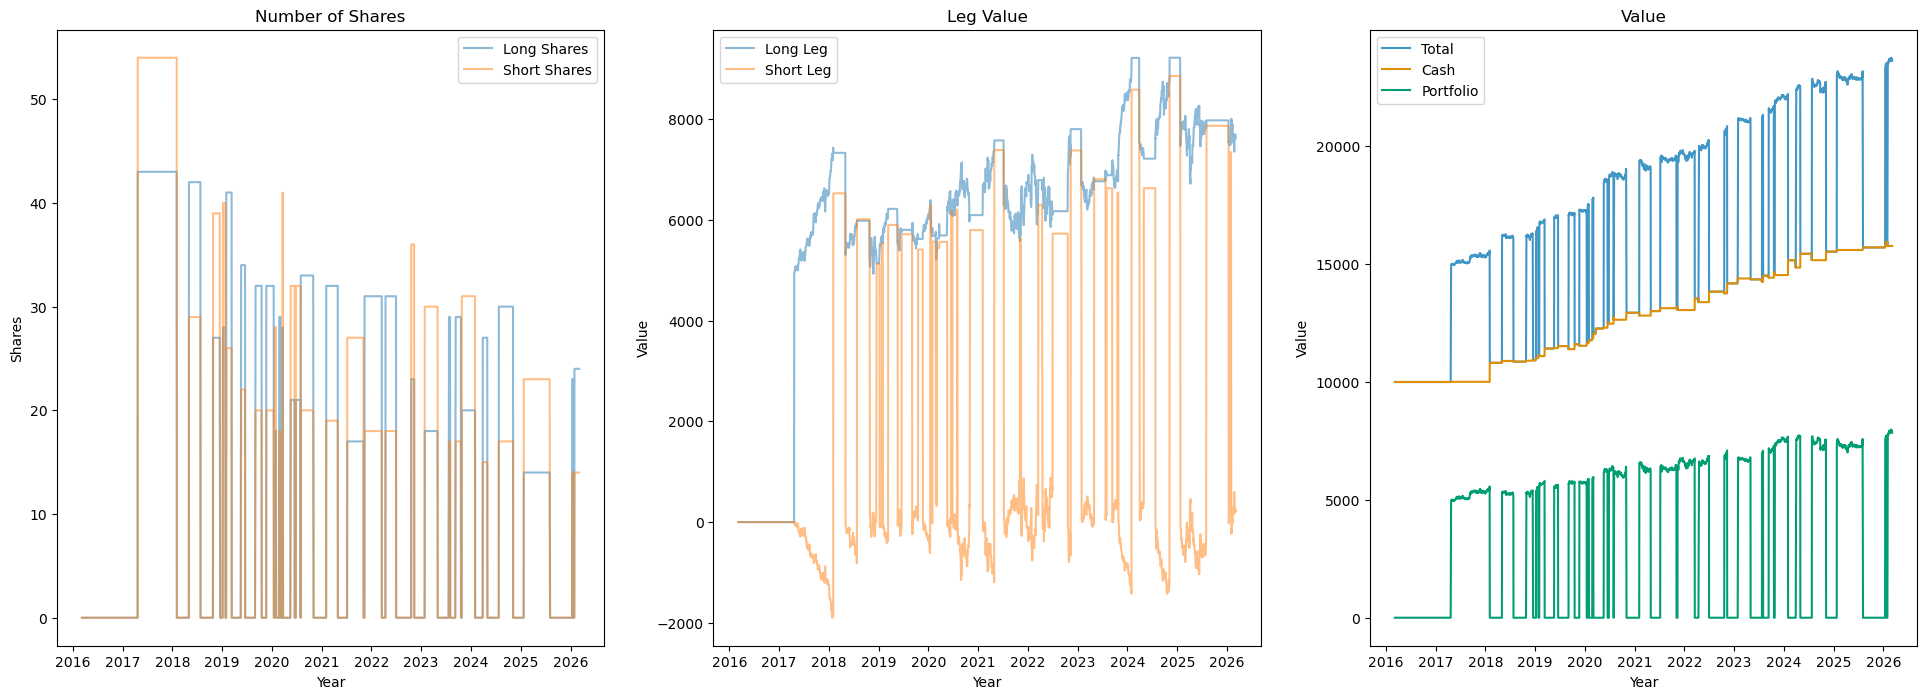

In [5]:
plt.figure(figsize=(24, 8))
colors = sns.color_palette("colorblind")

plt.subplot(1, 3, 1)
plt.plot(dataP.index,dataP['Long_Shares'],label='Long Shares',alpha=0.5)
plt.plot(dataP.index,dataP['Short_Shares'],label='Short Shares',alpha=0.5)
plt.title('Number of Shares')
plt.xlabel('Year')
plt.ylabel('Shares')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(dataP.index,dataP['Long_Leg'],label='Long Leg',alpha=0.5)
plt.plot(dataP.index,dataP['Short_Leg'],label='Short Leg',alpha=0.5)
plt.title('Leg Value')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(dataP.index,dataP['Total'],label='Total',alpha=0.75, color=colors[0])
plt.plot(dataP.index,dataP['Cash'],label='Cash', color=colors[1])
plt.plot(dataP.index,dataP['Portfolio_Value'],label='Portfolio', color=colors[2])
plt.title('Value')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()

plt.show()

## 5. Performance Metrics
After the backtesting is finished and we have calculated our portfolio value and cash over time, we calculate the most relevant metrics to compare both strategies with each other and to the S&P500 index and to each asset independently.  
We calculate the total returns, Sharpe ratio, maximum drawdown, compounding annual growth rate (CAGR), and Calmar ratio as single metrics. In addition, we calculate the yearly returns.  
This is done by the function `compute_metrics()`.

In [6]:
dataV, tableV, yV = compute_metrics(dataV,starting_capital)
dataM, tableM, yM = compute_metrics(dataM,starting_capital)
dataS, tableS, yS = compute_metrics(dataS,starting_capital)
dataP, tableP, yP = compute_metrics(dataP,starting_capital)

## 6. Results & Analysis
Finally, we show the results in the form of plots and a table for easier visualization.

The main results are shown as a triple plot:
1. The first one shows the equity curve on a daily basis, in which we compare the total value of our pairs trading strategy against buying and holding the same assets and the S&P500 index individually.
   - This is important as it shows how much our total portfolio value grows (or drops) in the same time period under different strategies.
2. The second plot shows the drawdowns on a daily basis, where we compare how much our portfolio has dropped in relation to the previous peaks for all three strategies.
    - This is important because it tells us how much our total value fluctuates compared to the other strategies.
3. The last plot shows the annual return, where as opposed to the total return metric, we show the return for each year.
   - This is important as it shows us if our portfolio has had some negative and positive years, which are not visible in the total return.

A table below shows the comparison of the main metrics for all strategies:
- Total Return
- Sharpe
- Max Drawdown
- CAGR
- Calmar

This is done by the function  `plot_performance()`.

,Pairs,V,MA,SPY
,Pairs,Buy Hold,Buy Hold,Buy Hold
Total Return,0.577204,3.411454,4.915515,2.352012
Sharpe,0.127837,0.447780,0.517638,0.452117
Max Drawdown,-0.020546,-0.363649,-0.409972,-0.341047
CAGR,0.046639,0.160071,0.194623,0.128631
Calmar,-2.269998,-0.440180,-0.474723,-0.377166


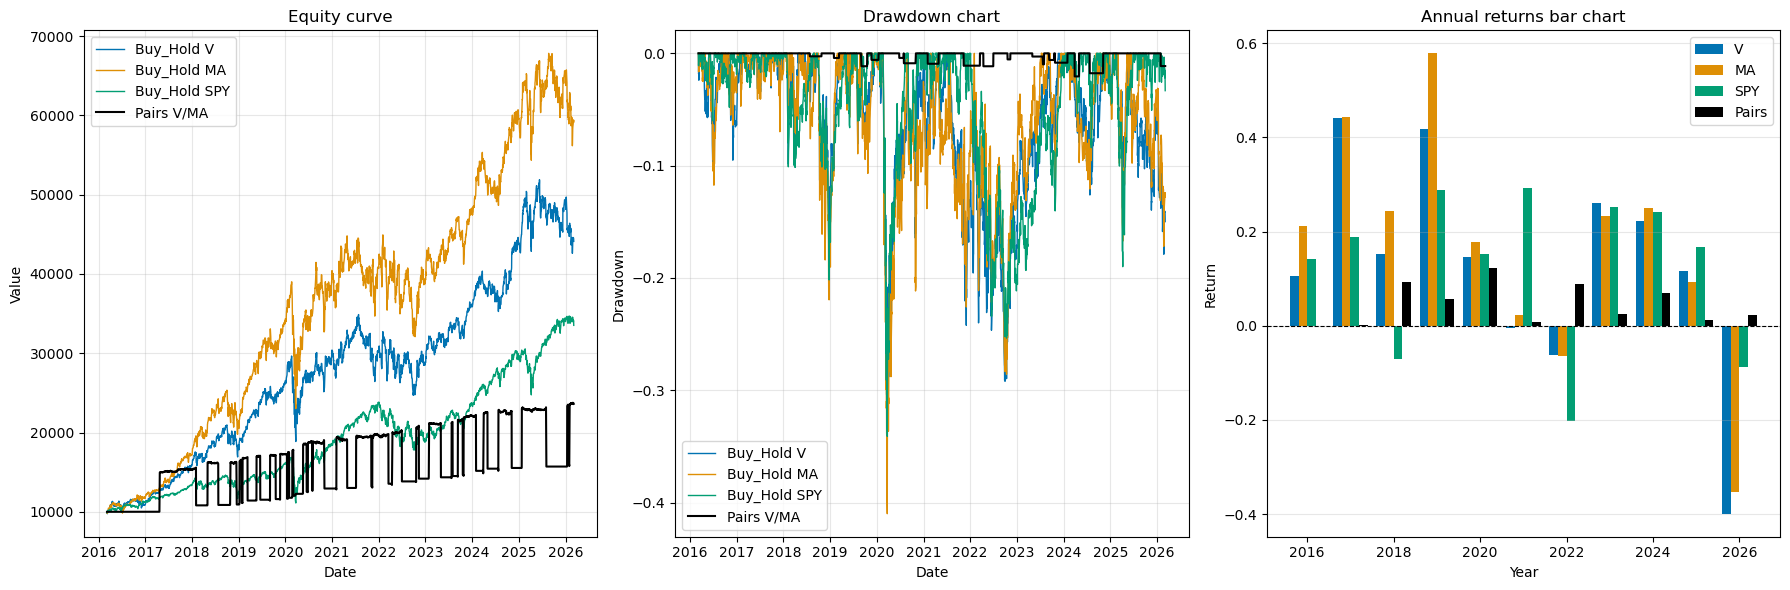

In [7]:
display(pd.concat([tableP, tableV, tableM, tableS], axis=1, keys=['Pairs', 'V', 'MA', 'SPY']))

plot_performance(dataV,dataM,dataS,dataP,yV,yM,yS,yP)

## 7. Conclusions

For this particular scenario with a 10k starting capital over a 10-year horizon for V & MA under the strategies of pairs trading compared to the buy-hold of SPY and each asset individually, we can draw the following conclusions:

- What did the strategy achieve?  
  The buy/sell strategy achieves great returns of 58%. Although the returns of buying and holding SPY (242%), V (345%), and MA (492%) seem much bigger than the strategy, the highlight here is the maximum drawdown. The strategy has a maximum drawdown for a mere 2%, while SPY, V, and MA are 34%, 41% and 36% respectively, meaning that the strategy is much more stable. The trade-off is a lower Sharpe ratio of 0.13, reflecting modest returns relative to volatility. However, when capital preservation is the objective, the near-zero drawdown justifies this trade-off.

- When does it work and when doesn't it?  
  The strategy seems to work best during times of uncertainty and high volatility, like the 2020 crisis. This period affected both assets independently, as well as the index, while the strategy showed little or no change.

- What would you change?  
  If risk and volatility are a concern for the investor, the strategy seems like the safer choice, if the trade-off of having lower returns is acceptable.

The strategy functions as a high volatility defense mechanism. It sacrifices returns for reduced drawdown. It is most suitable for risk-averse investors or as a complement to a core buy-and-hold position.

## 8. Limitations & Next Steps

The three most important limitations of this model are the following:  
1. Zero borrow rate - under real conditions, an annualized fee would have to be taken into account, as well as a margin requirement.
2. Cointegration instability — the cointegration relationship between V and MA was tested on historical data, but it can break down due to regulatory changes, competitive shifts, or macroeconomic regime changes. The strategy has no mechanism to detect when the relationship has permanently broken and will continue generating false signals indefinitely.
3. Realized vs unrealized P&L — metrics are calculated on realized cash (closed trades) rather than mark-to-market total value. This understates intraday volatility but more honestly reflects what the strategy actually delivered. A full implementation would report both.

Some interesting next steps to go deeper on this project would be:
- Add transaction costs
- Test across multiple pairs
- Look for which asset characteristics make the strategy work best

Just to name few.